In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
climate_data = pd.read_csv('../../data_files/data/climate_api_data_2016_2024.csv')
fire_data = pd.read_csv('../../data_files/data/inpe_fire_counts_data_2016_2024.csv')
defor_data = pd.read_csv('../../data_files/data/deter_notification_data/treated_deter_deforestation_data_2016_2024.csv')

# Merge data
climate_data = climate_data.merge(fire_data[['date', 'fire_counts']], on='date', how='left')
climate_data = climate_data.merge(defor_data[['date', 'total_degradation']], on='date', how='left')
climate_data['fire_counts'] = climate_data['fire_counts'].fillna(0)
climate_data['total_degradation'] = climate_data['total_degradation'].fillna(0)

# Extract actual environmental variables
temp_actual = climate_data['temp_med'].dropna().values
humid_actual = climate_data['umid_med'].dropna().values
rain_actual = climate_data['precip_med'].dropna().values
fire_actual = climate_data['fire_counts'].values
defor_actual = climate_data['total_degradation'].values

print('Environmental Data Summary (Manaus, Brazil 2016-2024)')
print('='*60)
print(f"Temperature:  min={temp_actual.min():.1f}°C, max={temp_actual.max():.1f}°C, mean={temp_actual.mean():.1f}°C")
print(f"Humidity:     min={humid_actual.min():.1f}%, max={humid_actual.max():.1f}%, mean={humid_actual.mean():.1f}%")
print(f"Precipitation: min={rain_actual.min():.1f}mm, max={rain_actual.max():.1f}mm, mean={rain_actual.mean():.1f}mm")
print(f"Fire counts:  min={fire_actual.min():.0f}, max={fire_actual.max():.0f}, mean={fire_actual.mean():.1f}")
print(f"Deforestation: min={defor_actual.min():.2f}km², max={defor_actual.max():.2f}km², mean={defor_actual.mean():.2f}km²")
print('='*60)


Environmental Data Summary (Manaus, Brazil 2016-2024)
Temperature:  min=23.1°C, max=32.5°C, mean=26.7°C
Humidity:     min=46.6%, max=95.9%, mean=83.3%
Precipitation: min=0.0mm, max=71.2mm, mean=3.7mm
Fire counts:  min=0, max=169, mean=0.9
Deforestation: min=0.00km², max=8.34km², mean=0.02km²


In [3]:
# ============================================================================
# MODEL PARAMETERS
# ============================================================================

T_prime = 19.9
B_E = 200
p_ME = 0.9
p_ML = 0.25
p_MP = 0.75
tau_E = 1
tau_P = 1
c1 = 0.00554
c2 = -0.06737
D1 = 36.5
A = -0.03
B = 1.31
C = -4.4
b1 = 0.04
b2 = 0.09

DD = 105
Tmin = 14.5
R_L = 32.67

defor_max_effect = 0.30
defor_scale = 0.0001
fire_smoke_effect = 0.40
fire_habitat_effect = 0.20


In [4]:
# Critical temperatures for Plasmodium development
optimal_temp_plasm = 23.5
critical_max_temp_plasm = 29.8
#critical_min_temp_plasm = 14.5 # Tmin

# Critical temperatures for Anopheles development
optimal_temp_anop = 25 #26
critical_max_temp_anop = 34 #40
critical_min_temp_anop = 16 #10

In [20]:
# ============================================================================
# MOSQUITO LIFE CYCLE FUNCTIONS
# ============================================================================

def tau_L(Temp):
    denominator = c1 * Temp + c2
    result = np.where(denominator <= 0, np.inf, 1.0 / denominator)
    return result

def p_T(Temp, Umid):
    denominator = A * Temp**2 + B * Temp + C
    if denominator <= 0:
        p_T_temp = 0.0
    else:
        p_T_temp = np.exp(-1/denominator)
    
    if Umid < 50:
        p_U = 0.0
    elif Umid < 60:
        p_U = (Umid - 50) / 10
    else:
        p_U = 1.0
    
    return p_T_temp * p_U

def p_LT(Temp):
    exponent = c1 * Temp + c2
    return np.exp(-exponent)

def p_LR(Rain, R_L):
    if Rain < 0 or Rain > R_L:
        return 0
    return (4 * p_ML / R_L**2) * Rain * (R_L - Rain)

def p_ER(Rain, R_L):
    if Rain < 0 or Rain > R_L:
        return 0
    return (4 * p_ME / R_L**2) * Rain * (R_L - Rain)

def p_PR(Rain, R_L):
    if Rain < 0 or Rain > R_L:
        return 0
    return (4 * p_MP / R_L**2) * Rain * (R_L - Rain)

def tau_M(Temp):
    if Temp <= Tmin:
        return np.inf
    return DD / (Temp - Tmin)

def mu(Temp, Umid):
    p_T_val = p_T(Temp, Umid)
    if p_T_val <= 0:
        return np.inf
    mu_val = -np.log(p_T_val)
    return mu_val

def a(Temp):
    a_val = np.maximum(0, (Temp - T_prime) / D1)
    return a_val

def a_with_fire(Temp, fire_counts, fire_smoke_effect):
    base_rate = a(Temp)
    fire_intensity = min(fire_counts / 50.0, 1.0)
    smoke_reduction = fire_smoke_effect * fire_intensity
    return base_rate * (1 - smoke_reduction)

def b_rate(Rain, Temp, R_L):
    tau_L_curr = tau_L(Temp)
    numerator = B_E * p_ER(Rain, R_L) * p_LR(Rain, R_L) * p_LT(Temp) * p_PR(Rain, R_L)
    denominator = tau_E + tau_L_curr + tau_P
    if denominator <= 0 or tau_L_curr == np.inf:
        return 0
    return numerator / denominator

def b_rate_with_environment(Rain, Temp, R_L, fire_counts, total_degradation):
    base_rate = b_rate(Rain, Temp, R_L)
    defor_effect = min(total_degradation * defor_scale, defor_max_effect)
    fire_intensity = min(fire_counts / 50.0, 1.0)
    fire_habitat_destruction = fire_habitat_effect * fire_intensity
    net_effect = (1 + defor_effect) * (1 - fire_habitat_destruction)
    return base_rate * net_effect

def mu_with_fire(Temp, Umid, fire_counts, fire_habitat_effect):
    base_mu = mu(Temp, Umid)
    fire_intensity = min(fire_counts / 50.0, 1.0)
    fire_mortality_increase = 0.15 * fire_intensity
    return min(base_mu + fire_mortality_increase, 0.5)

print('Functions loaded successfully!')

Functions loaded successfully!


In [6]:
climate_data['date'] = pd.to_datetime(climate_data['date'])

# Use the actual temperature data from your climate dataset
date_range = climate_data['date'].dropna().values

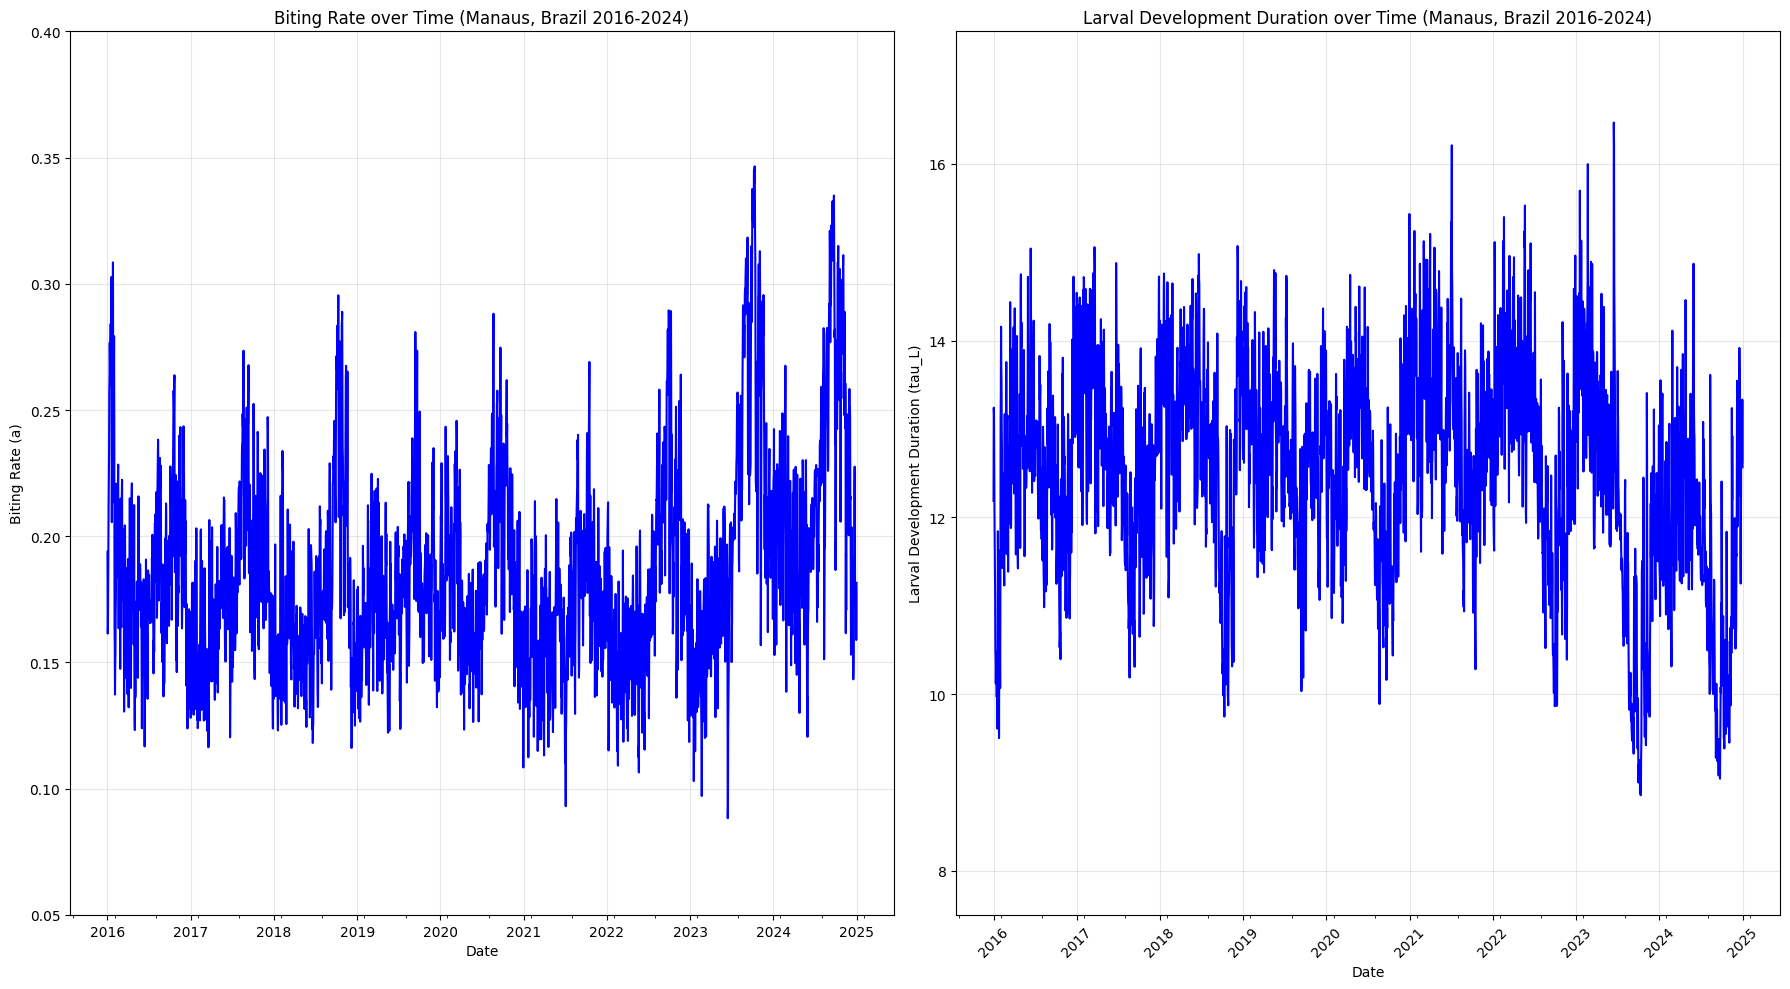

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# 1) Plot a vs time
a_over_time = a(temp_actual)

axes[0].plot(date_range, a_over_time, 'b-', linewidth=1.5)
axes[0].axhline(y=0, color='gray', linestyle='-', alpha=0.3)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Biting Rate (a)')
axes[0].set_title('Biting Rate over Time (Manaus, Brazil 2016-2024)')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0.05, 0.4)  

# 2) Plot tau_L vs time
tau_L_over_time = tau_L(temp_actual)

axes[1].plot(date_range, tau_L_over_time, 'b-', linewidth=1.5)
axes[1].axhline(y=0, color='gray', linestyle='-', alpha=0.3)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Larval Development Duration (tau_L)')
axes[1].set_title('Larval Development Duration over Time (Manaus, Brazil 2016-2024)')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(7.5, 17.5)  

# Simplify x-axis for both subplots
import matplotlib.dates as mdates
for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=6))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()